# Analyse Exploratoire — Projet Data Centre d'Assistance
## DU Big Data & Data Science — Université de Montpellier 2025-2026
### Équipe : Randriamisaina Tsiory-Fanomezana · SHIRALI POUR Amir

Ce notebook réalise l'analyse exploratoire complète du dataset final (`dataset_complet.csv`).

**Plan :**
1. Chargement et aperçu global
2. Analyse univariée — variables numériques (`analyse_var`)
3. Analyse univariée — variables catégorielles
4. Analyse bivariée — durée vs variables explicatives
5. Analyse temporelle et saisonnalité
6. Synthèse et conclusions

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Détection de la racine du projet
def _racine():
    rep = Path().resolve()
    while True:
        if any((rep / m).exists() for m in ['.git', 'requirements.txt']):
            return rep
        if rep.parent == rep:
            return Path().resolve().parent
        rep = rep.parent

RACINE = _racine()
print(f'Racine du projet : {RACINE}')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
BLEU = '#4472C4'; ORANGE = '#ED7D31'; VERT = '#70AD47'; ROUGE = '#C00000'

Racine du projet : /Users/su6i/Documents/DU/Projet Data/projet_big_data_v2


## 1. Chargement et aperçu global

In [2]:
df = pd.read_csv(RACINE / 'data' / 'dataset_complet.csv', encoding='utf-8')
df['date.ouverture'] = pd.to_datetime(df['date.ouverture'], errors='coerce')

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Période : {df["date.ouverture"].dt.year.min()} – {df["date.ouverture"].dt.year.max()}')
print(f'Agents uniques : {df["Matricule.de.traitement"].nunique():,}')
df.head(3)

Dimensions : 98,935 lignes × 34 colonnes
Période : 2021 – 2022
Agents uniques : 2,334


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,...,agent_population,agent_site,agent_contrat,agent_duree_travail_j,agent_temps_travail_pct,agent_experience_j,delai_survenance_ouverture_j,mois_ouverture,annee_ouverture,duree_totale_h
0,7494402,C5,F99,2021-11-02,10:38:00,326,Panne mécanique,2021/11/02,Diesel,MCS,...,CAS,A,CDI,3.666666,70.0,1678.0,0,11,2021,10.38
1,7569082,C4,F14,2022-12-07,18:40:00,1164,Panne mécanique,2022/12/07,Essence,MCS,...,CAS,A,CDI,7.333333,70.0,2143.0,0,12,2022,4.73
2,8111190,C0,F1,2021-08-01,12:32:00,1337,Panne mécanique,2021/08/01,Essence,MCS,...,CAS,A,CDI,1.750000,70.0,1814.0,0,8,2021,30.82


In [3]:
# Taux de valeurs manquantes par colonne
nan_pct = (df.isna().mean() * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]
print('Colonnes avec valeurs manquantes :')
print(nan_pct.to_string())

Colonnes avec valeurs manquantes :
duree_moyenne_min              13.050993
Assistance.ou.Administratif     9.878203
agent_experience_j              7.453378
agent_temps_travail_pct         7.453378
agent_duree_travail_j           7.453378
agent_contrat                   7.453378
agent_site                      7.453378
agent_population                7.453378
agent_lieu_travail              7.453378
Formule                         5.896801
nb_interventions                2.203467
nb_agents_distincts             2.203467
date_derniere_intervention      2.203467
date_premiere_intervention      2.203467
duree_totale_min                2.203467
duree_totale_h                  2.203467
heure.ouverture                 0.988528
Cause.intervention              0.983474
Type.d.energie                  0.980442


## 2. Analyse univariée — variables numériques

Fonction `analyse_var` : stats descriptives + histogramme + boxplot + test de normalité.

In [4]:
def analyse_var(df, var, titre=None):
    """Analyse univariée complète d'une variable numérique."""
    serie = df[var].dropna()
    titre = titre or var

    print(f'=== {titre} ({len(serie):,} valeurs non-NaN) ===')
    print(serie.describe().round(2).to_string())
    print(f'  Asymétrie (skewness) : {serie.skew():.3f}')
    print(f'  Kurtosis             : {serie.kurt():.3f}')

    # Test de normalité (Shapiro sur échantillon)
    sample = serie.sample(min(5000, len(serie)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f'  Shapiro-Wilk         : W={stat:.4f}, p={p:.4e} → {"NON normale" if p < 0.05 else "normale"}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(titre, fontsize=13, fontweight='bold')

    # Histogramme
    p99 = serie.quantile(0.99)
    axes[0].hist(serie[serie <= p99], bins=50, color=BLEU, edgecolor='white')
    axes[0].axvline(serie.median(), color=ROUGE, linestyle='--', label=f'Médiane={serie.median():.1f}')
    axes[0].axvline(serie.mean(), color=ORANGE, linestyle='--', label=f'Moyenne={serie.mean():.1f}')
    axes[0].set_title('Distribution (p99)')
    axes[0].legend(fontsize=9)

    # Boxplot
    axes[1].boxplot(serie, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=BLEU, alpha=0.7))
    axes[1].set_title('Boxplot')
    axes[1].set_ylabel(var)

    # QQ-plot
    stats.probplot(sample, dist='norm', plot=axes[2])
    axes[2].set_title('QQ-plot (normalité)')

    plt.tight_layout()
    plt.show()
    print()

=== Durée totale de traitement (heures) (96,755 valeurs non-NaN) ===
count    96755.00
mean        19.96
std         35.78
min          0.00
25%          4.48
50%          9.38
75%         21.23
max       4271.70
  Asymétrie (skewness) : 21.864
  Kurtosis             : 2107.580
  Shapiro-Wilk         : W=0.5677, p=4.9081e-77 → NON normale


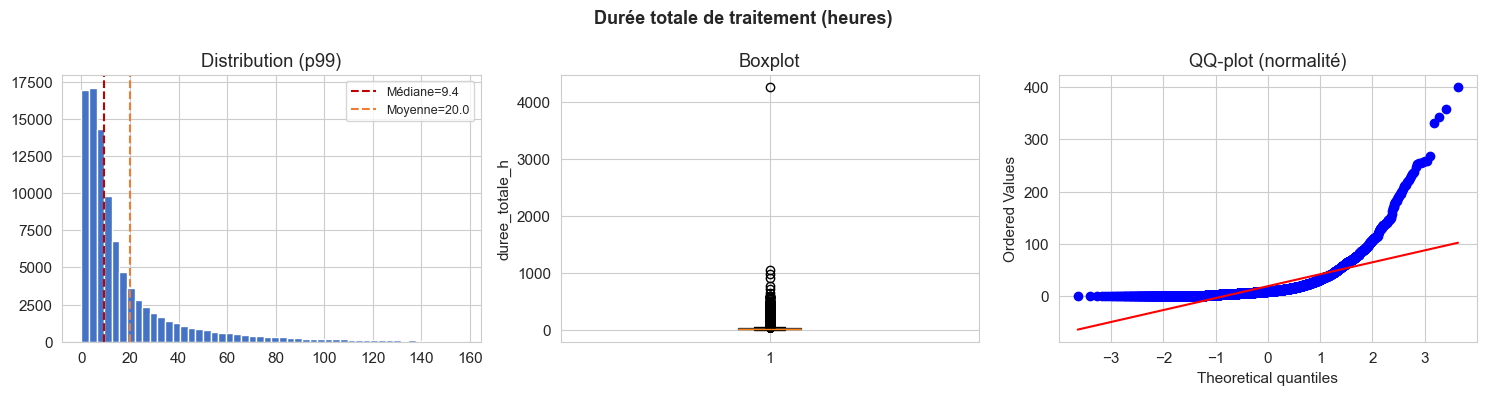


=== Expérience de l'agent (jours) (91,561 valeurs non-NaN) ===
count    91561.00
mean      1111.53
std       1364.68
min          0.00
25%        139.00
50%        422.00
75%       1804.00
max       6186.00
  Asymétrie (skewness) : 1.415
  Kurtosis             : 1.092
  Shapiro-Wilk         : W=0.7736, p=5.8985e-64 → NON normale


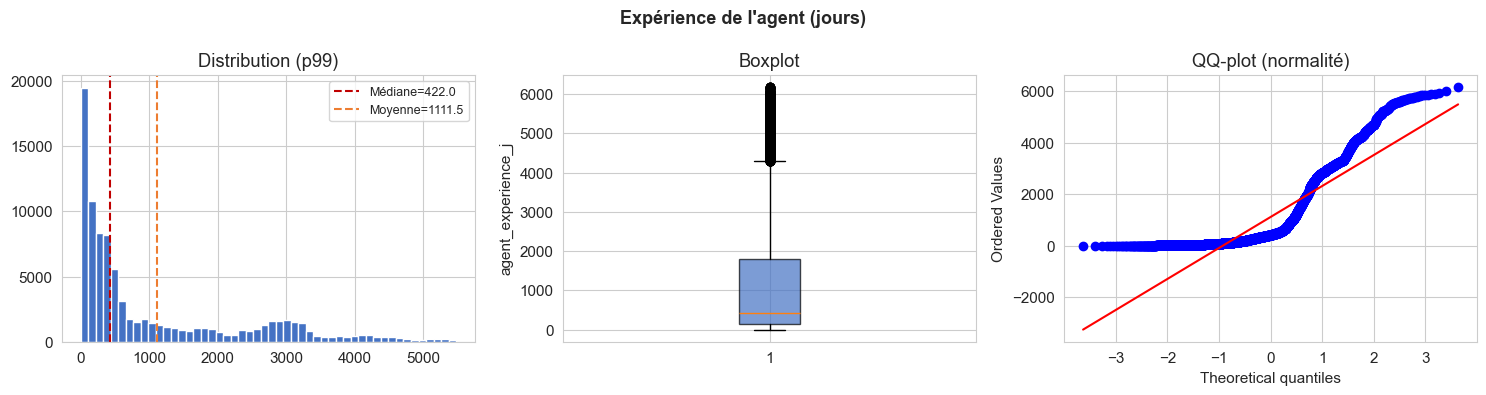


=== Durée de travail de l'agent (jours) (91,561 valeurs non-NaN) ===
count    91561.00
mean         6.44
std          1.48
min          0.08
25%          5.50
50%          7.33
75%          7.33
max         15.00
  Asymétrie (skewness) : -1.604
  Kurtosis             : 1.976
  Shapiro-Wilk         : W=0.7136, p=1.4540e-68 → NON normale


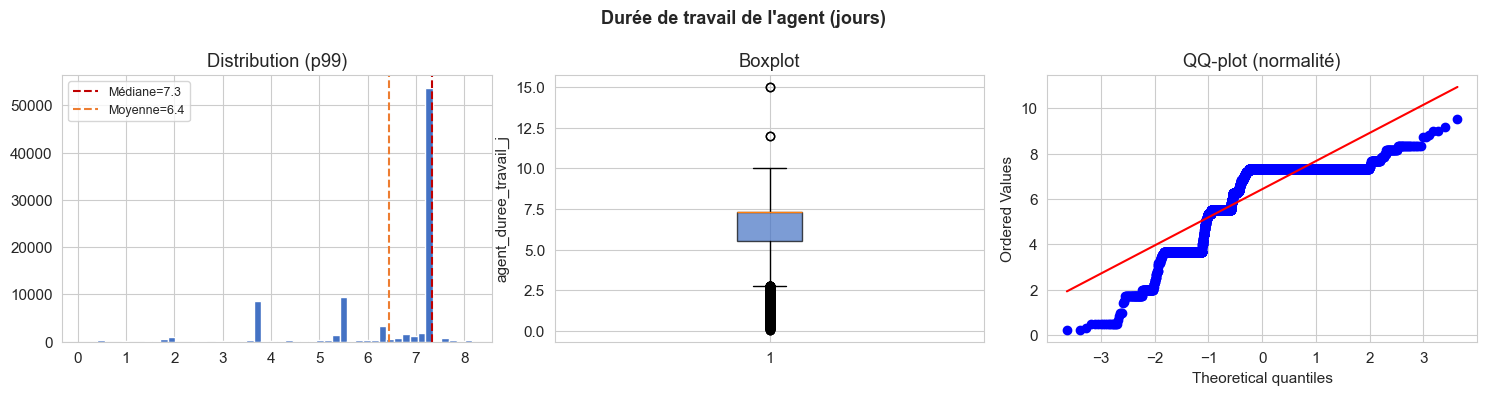


=== Taux de temps de travail (%) (91,561 valeurs non-NaN) ===
count    91561.00
mean        72.53
std          9.37
min         30.00
25%         70.00
50%         70.00
75%         80.00
max        100.00
  Asymétrie (skewness) : -0.118
  Kurtosis             : 4.245
  Shapiro-Wilk         : W=0.7616, p=5.9098e-65 → NON normale


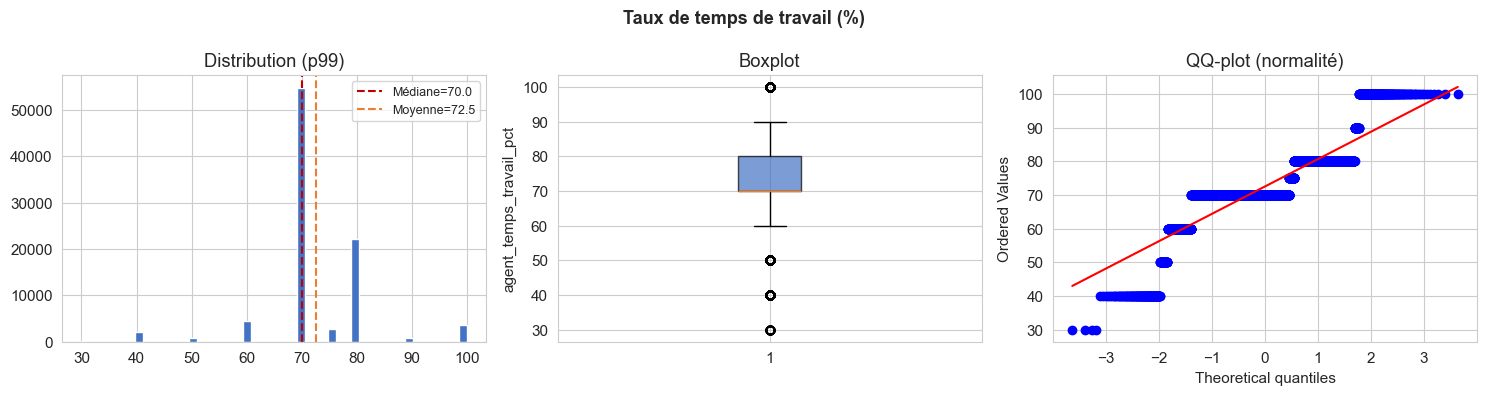


=== Nombre d'interventions par dossier (96,755 valeurs non-NaN) ===
count    96755.00
mean         4.31
std          6.20
min          1.00
25%          1.00
50%          2.00
75%          5.00
max        178.00
  Asymétrie (skewness) : 6.150
  Kurtosis             : 75.284
  Shapiro-Wilk         : W=0.4971, p=2.8305e-80 → NON normale


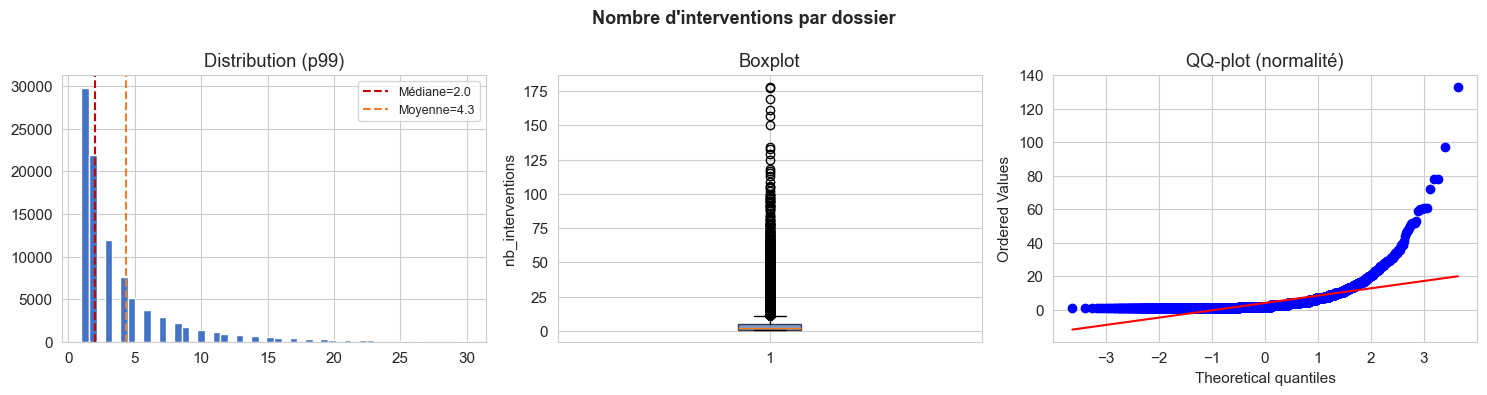


=== Nombre d'agents distincts par dossier (96,755 valeurs non-NaN) ===
count    96755.00
mean         3.19
std          3.78
min          1.00
25%          1.00
50%          2.00
75%          4.00
max        110.00
  Asymétrie (skewness) : 5.118
  Kurtosis             : 53.696
  Shapiro-Wilk         : W=0.5688, p=5.5464e-77 → NON normale


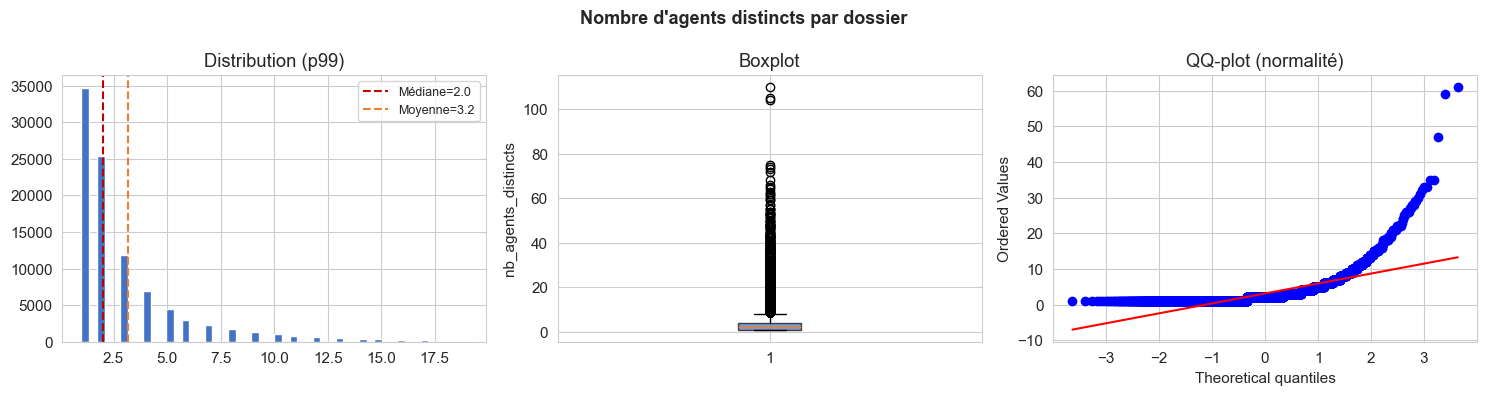


=== Délai survenance → ouverture (jours) (98,935 valeurs non-NaN) ===
count    98935.00
mean         2.19
std         16.97
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        670.00
  Asymétrie (skewness) : 13.014
  Kurtosis             : 229.678
  Shapiro-Wilk         : W=0.1100, p=4.1034e-93 → NON normale


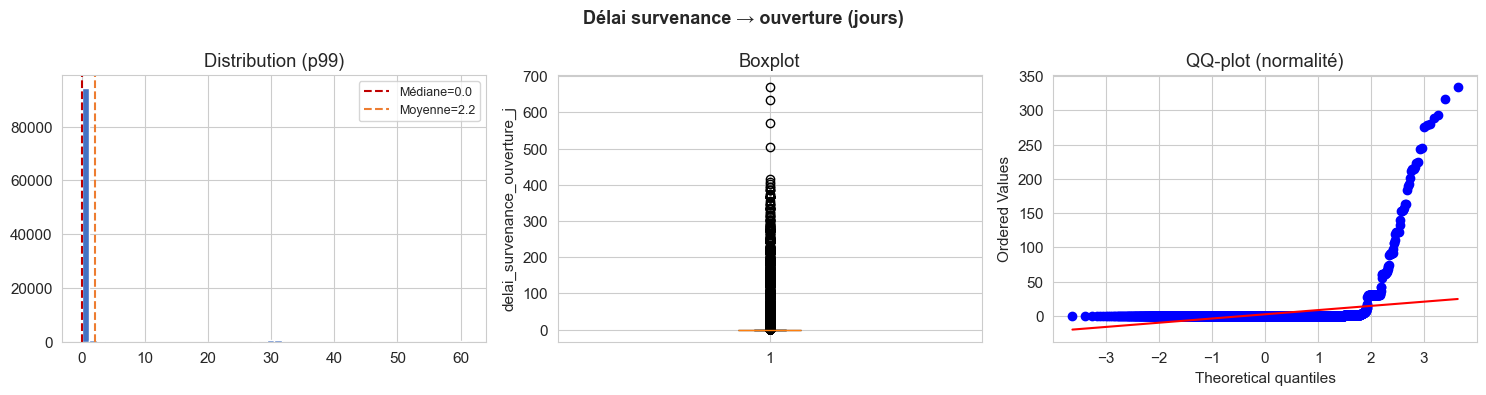

In [5]:
# Variables numériques à analyser
vars_num = [
    ('duree_totale_h',              'Durée totale de traitement (heures)'),
    ('agent_experience_j',          'Expérience de l\'agent (jours)'),
    ('agent_duree_travail_j',        'Durée de travail de l\'agent (jours)'),
    ('agent_temps_travail_pct',      'Taux de temps de travail (%)'),
    ('nb_interventions',             'Nombre d\'interventions par dossier'),
    ('nb_agents_distincts',          'Nombre d\'agents distincts par dossier'),
    ('delai_survenance_ouverture_j', 'Délai survenance → ouverture (jours)'),
]

for var, titre in vars_num:
    if var in df.columns:
        analyse_var(df, var, titre)

## 3. Analyse univariée — variables catégorielles

=== Cause d'intervention ===
  Modalités : 7
  Top 5 :
Cause.intervention
Panne mécanique               66720
Accident                      15659
Clés, Carburant, Crevaison    11428
Vol / Vandalisme               2217
Autres                         1428


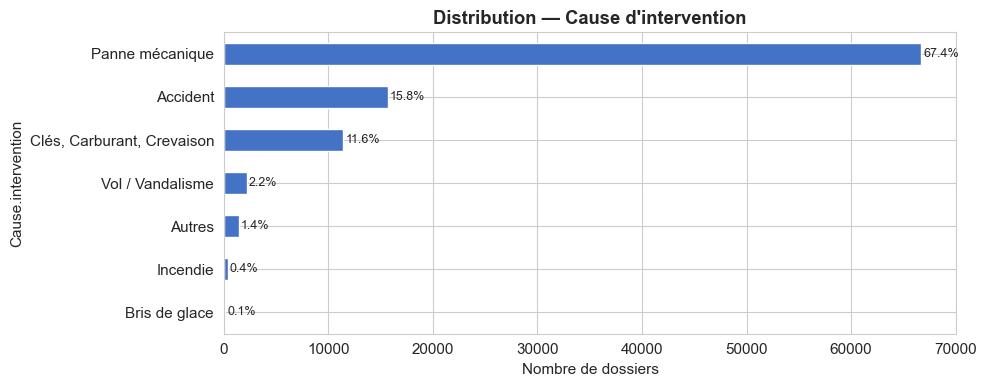


=== Formule du contrat ===
  Modalités : 362
  Top 5 :
Formule
F4    16788
F6     7361
F8     5578
F0     5430
F1     4381


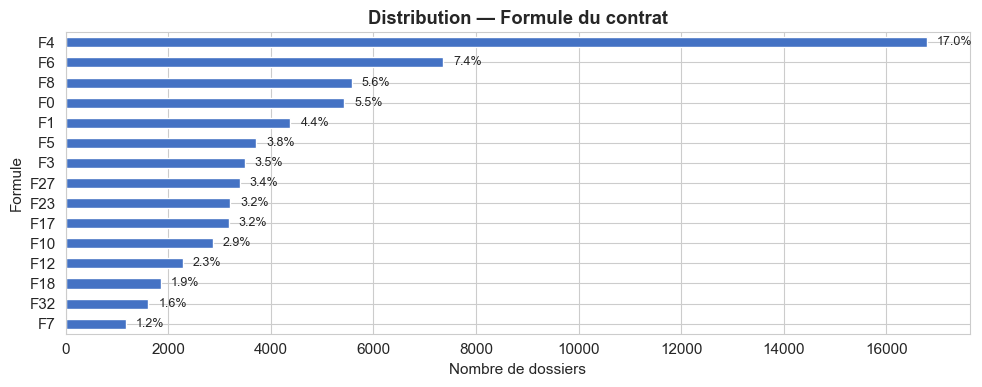

=== Type de contrat agent ===
  Modalités : 3
  Top 5 :
agent_contrat
CDI    51515
CDD    31596
CDS     8450


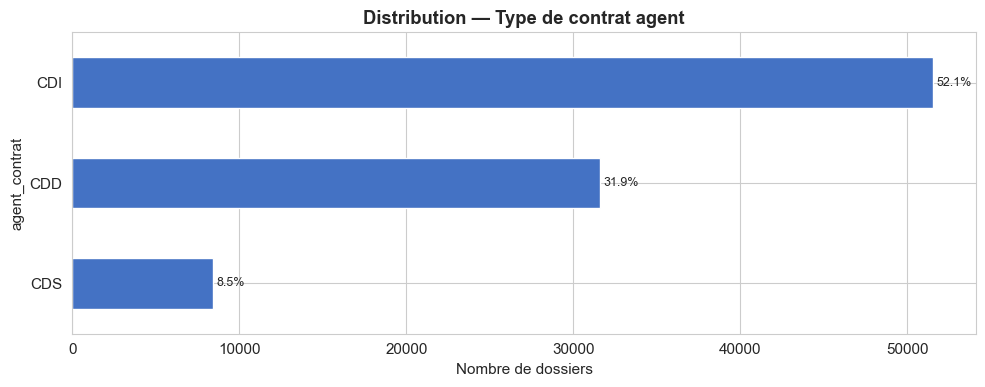


=== Lieu de travail agent ===
  Modalités : 2
  Top 5 :
agent_lieu_travail
SITE    46837
TELE    44724


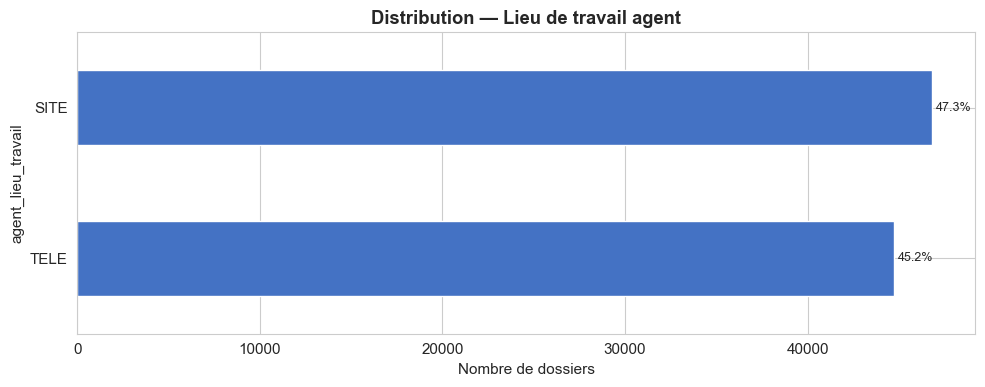


=== Population agent ===
  Modalités : 2
  Top 5 :
agent_population
CAS    84774
CAC     6787


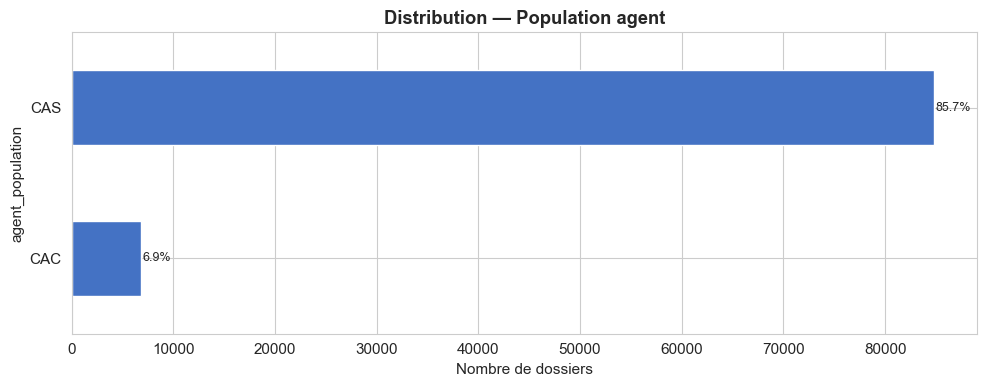


=== Client ===
  Modalités : 69
  Top 5 :
Client
C4     29578
C1     22034
C3     16243
C7      5444
C10     5178


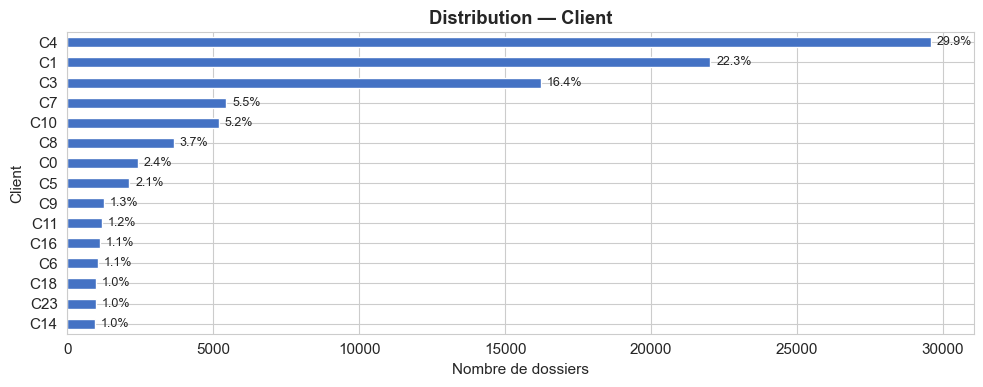


=== Type d'énergie ===
  Modalités : 7
  Top 5 :
Type.d.energie
Diesel         53404
Essence        35061
Autre           4496
Hybride         2421
Electricité     1706


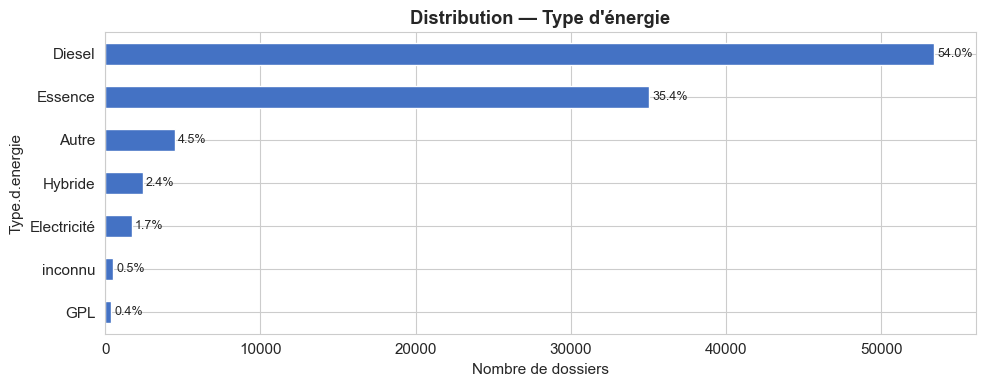

In [6]:
def analyse_cat(df, var, titre=None, top_n=15):
    """Analyse univariée d'une variable catégorielle."""
    serie = df[var].dropna()
    titre = titre or var
    vc = serie.value_counts()

    print(f'=== {titre} ===')
    print(f'  Modalités : {serie.nunique()}')
    print(f'  Top 5 :\n{vc.head().to_string()}')

    fig, ax = plt.subplots(figsize=(10, 4))
    vc.head(top_n).sort_values().plot(kind='barh', ax=ax, color=BLEU, edgecolor='white')
    ax.set_title(f'Distribution — {titre}', fontweight='bold')
    ax.set_xlabel('Nombre de dossiers')
    for i, v in enumerate(vc.head(top_n).sort_values()):
        ax.text(v + len(df)*0.002, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print()

vars_cat = [
    ('Cause.intervention',   'Cause d\'intervention'),
    ('Formule',              'Formule du contrat'),
    ('agent_contrat',        'Type de contrat agent'),
    ('agent_lieu_travail',   'Lieu de travail agent'),
    ('agent_population',     'Population agent'),
    ('Client',               'Client'),
    ('Type.d.energie',       'Type d\'énergie'),
]

for var, titre in vars_cat:
    if var in df.columns:
        analyse_cat(df, var, titre)

## 4. Analyse bivariée — Durée de traitement vs variables explicatives

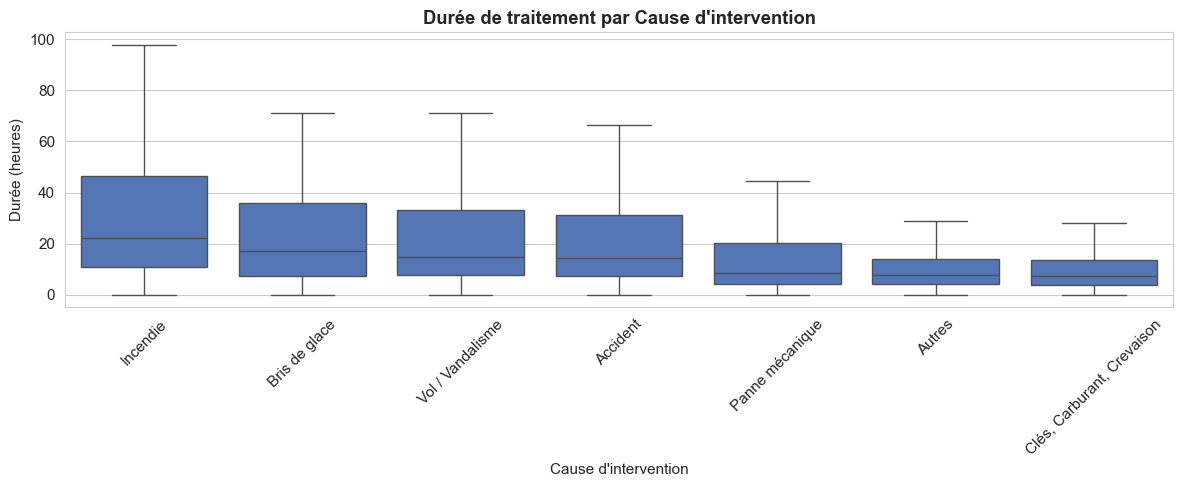

In [7]:
duree_valide = df.dropna(subset=['duree_totale_h'])

# 4.1 Durée par Cause d'intervention — boxplot + test Kruskal-Wallis
fig, ax = plt.subplots(figsize=(12, 5))
causes_order = (duree_valide.groupby('Cause.intervention')['duree_totale_h']
                .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=duree_valide, x='Cause.intervention', y='duree_totale_h',
            ax=ax, order=causes_order, showfliers=False, color=BLEU)
ax.set_title("Durée de traitement par Cause d'intervention", fontweight="bold")
ax.set_xlabel("Cause d'intervention")
ax.set_ylabel('Durée (heures)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

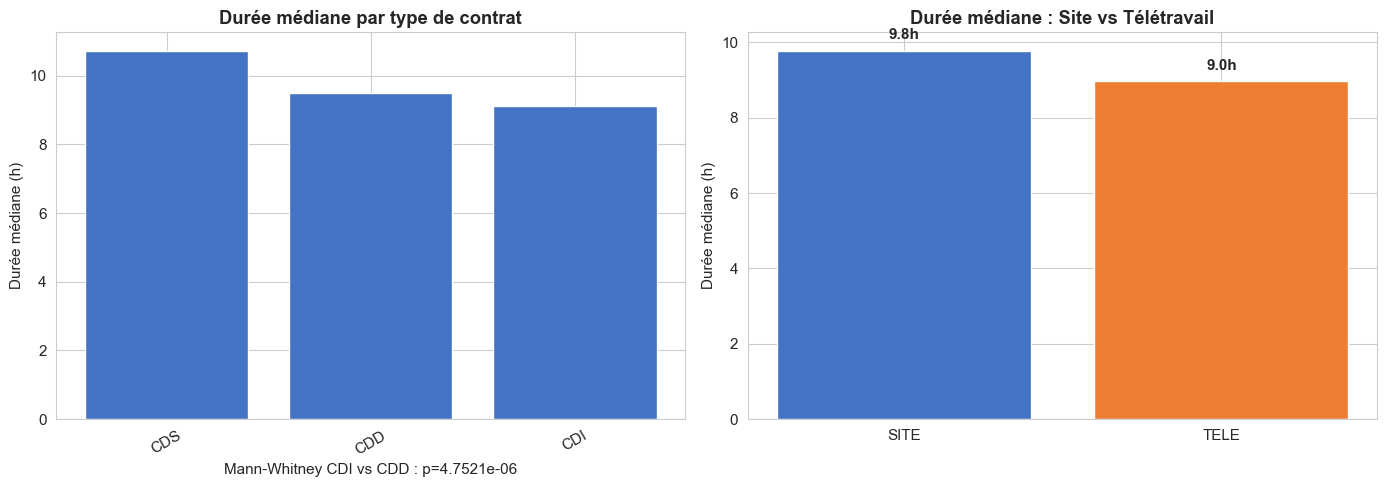

In [8]:
# 4.2 Durée par type de contrat agent
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contrats = duree_valide.groupby('agent_contrat')['duree_totale_h']
medians = contrats.median().sort_values(ascending=False)
axes[0].bar(medians.index, medians.values, color=BLEU, edgecolor='white')
axes[0].set_title('Durée médiane par type de contrat', fontweight='bold')
axes[0].set_ylabel('Durée médiane (h)')
axes[0].tick_params(axis='x', rotation=30)

# Test Mann-Whitney CDI vs CDD
if 'CDI' in duree_valide['agent_contrat'].values and 'CDD' in duree_valide['agent_contrat'].values:
    cdi = duree_valide[duree_valide['agent_contrat'] == 'CDI']['duree_totale_h']
    cdd = duree_valide[duree_valide['agent_contrat'] == 'CDD']['duree_totale_h']
    u, p = stats.mannwhitneyu(cdi, cdd, alternative='two-sided')
    axes[0].set_xlabel(f'Mann-Whitney CDI vs CDD : p={p:.4e}')

# Lieu de travail SITE vs TELE
lieu = duree_valide.groupby('agent_lieu_travail')['duree_totale_h'].median()
axes[1].bar(lieu.index, lieu.values, color=[BLEU, ORANGE], edgecolor='white')
axes[1].set_title('Durée médiane : Site vs Télétravail', fontweight='bold')
axes[1].set_ylabel('Durée médiane (h)')
for i, v in enumerate(lieu.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}h', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

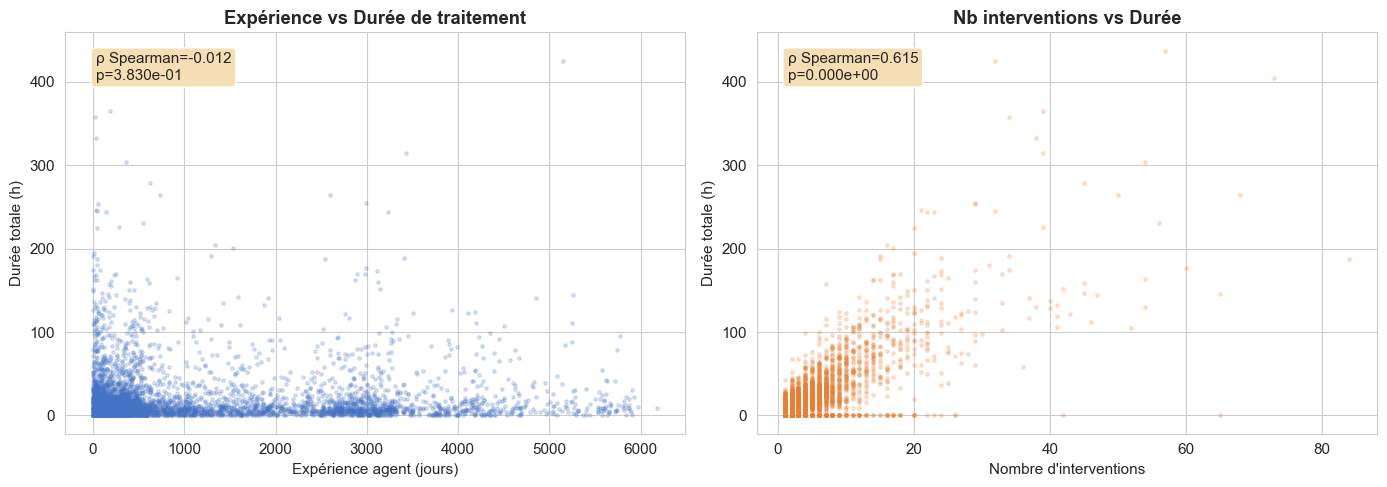

In [9]:
# 4.3 Expérience agent vs durée — scatter + corrélation de Spearman
sample = duree_valide.dropna(subset=['agent_experience_j']).sample(min(5000, len(duree_valide)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['agent_experience_j'], sample['duree_totale_h'],
                alpha=0.2, s=6, color=BLEU)
axes[0].set_xlabel('Expérience agent (jours)')
axes[0].set_ylabel('Durée totale (h)')
axes[0].set_title('Expérience vs Durée de traitement', fontweight='bold')

rho, p = stats.spearmanr(sample['agent_experience_j'], sample['duree_totale_h'])
axes[0].text(0.05, 0.95, f'ρ Spearman={rho:.3f}\np={p:.3e}',
             transform=axes[0].transAxes, va='top', bbox=dict(boxstyle='round', facecolor='wheat'))

# Nb interventions vs durée
axes[1].scatter(sample['nb_interventions'], sample['duree_totale_h'],
                alpha=0.2, s=6, color=ORANGE)
axes[1].set_xlabel('Nombre d\'interventions')
axes[1].set_ylabel('Durée totale (h)')
axes[1].set_title('Nb interventions vs Durée', fontweight='bold')

rho2, p2 = stats.spearmanr(sample['nb_interventions'], sample['duree_totale_h'])
axes[1].text(0.05, 0.95, f'ρ Spearman={rho2:.3f}\np={p2:.3e}',
             transform=axes[1].transAxes, va='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

## 5. Analyse temporelle et saisonnalité

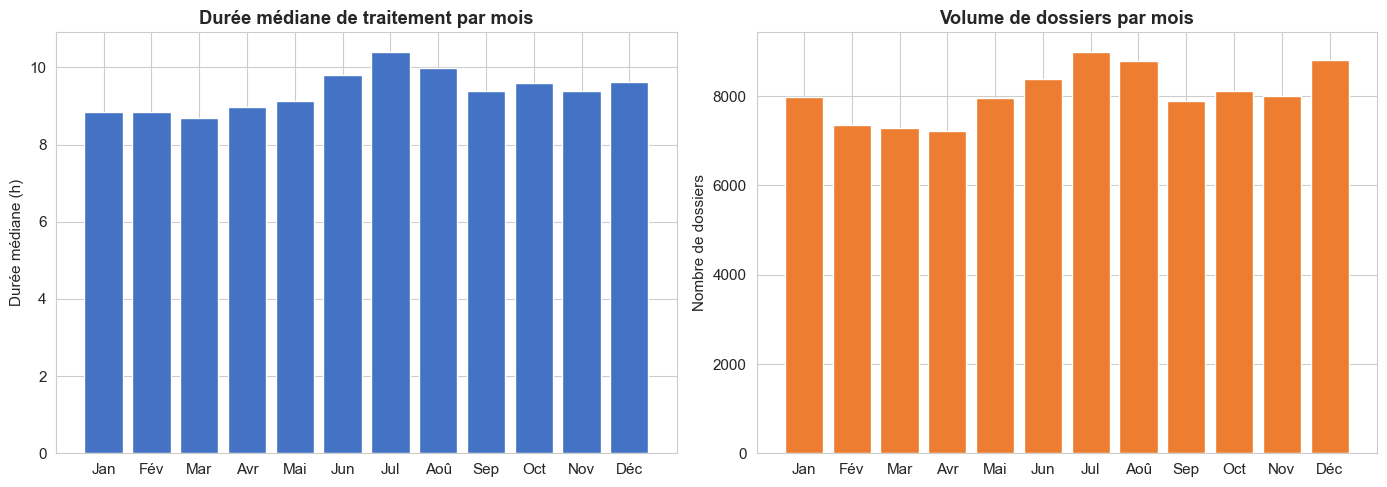

In [10]:
# 5.1 Durée médiane par mois
duree_mois = duree_valide.groupby('mois_ouverture')['duree_totale_h'].agg(['median', 'mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
axes[0].bar(duree_mois.index, duree_mois['median'], color=BLEU, edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(mois_labels)
axes[0].set_title('Durée médiane de traitement par mois', fontweight='bold')
axes[0].set_ylabel('Durée médiane (h)')

# Volume de dossiers par mois
axes[1].bar(duree_mois.index, duree_mois['count'], color=ORANGE, edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(mois_labels)
axes[1].set_title('Volume de dossiers par mois', fontweight='bold')
axes[1].set_ylabel('Nombre de dossiers')

plt.tight_layout()
plt.show()

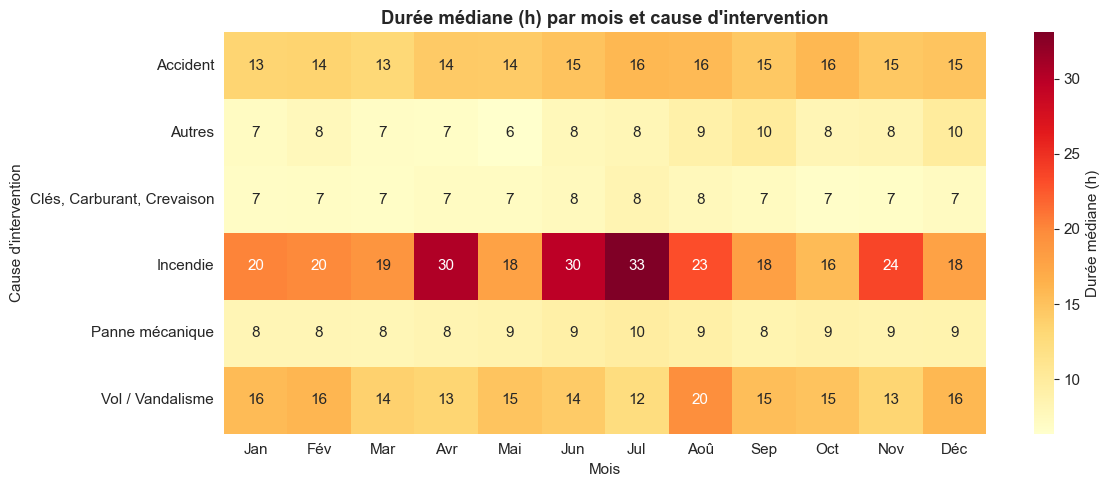

In [11]:
# 5.2 Heatmap mois × cause — durée médiane
top_causes = duree_valide['Cause.intervention'].value_counts().head(6).index
df_heat = (duree_valide[duree_valide['Cause.intervention'].isin(top_causes)]
           .groupby(['mois_ouverture', 'Cause.intervention'])['duree_totale_h']
           .median().unstack())

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df_heat.T, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=mois_labels, ax=ax, cbar_kws={'label': 'Durée médiane (h)'})
ax.set_title('Durée médiane (h) par mois et cause d\'intervention', fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Cause d\'intervention')
plt.tight_layout()
plt.show()

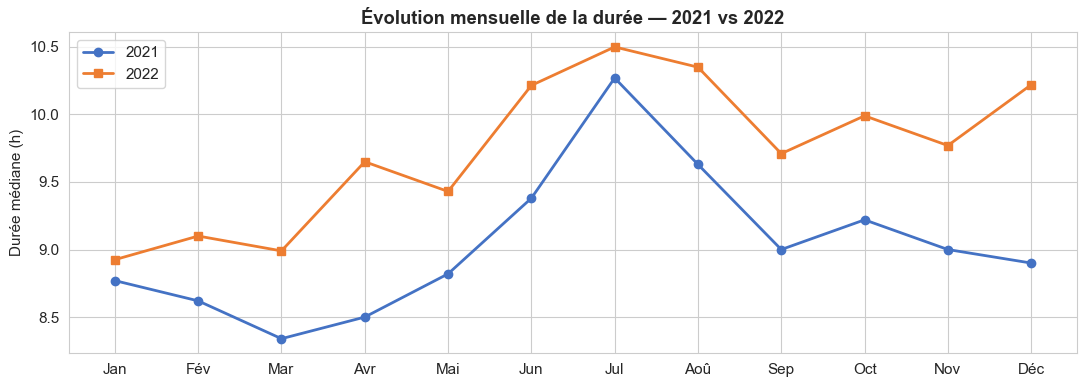

In [12]:
# 5.3 Évolution mensuelle 2021 vs 2022
df_evol = (duree_valide.groupby(['annee_ouverture', 'mois_ouverture'])['duree_totale_h']
           .median().reset_index())

fig, ax = plt.subplots(figsize=(11, 4))
for annee, couleur, style in [(2021, BLEU, '-o'), (2022, ORANGE, '-s')]:
    d = df_evol[df_evol['annee_ouverture'] == annee]
    ax.plot(d['mois_ouverture'], d['duree_totale_h'],
            style, color=couleur, label=str(annee), linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_ylabel('Durée médiane (h)')
ax.set_title('Évolution mensuelle de la durée — 2021 vs 2022', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Synthèse et conclusions

### Principaux enseignements

**Distribution de la variable cible (`duree_totale_h`) :**
- Distribution fortement asymétrique à droite (skewness > 0)
- Non-normale (Shapiro-Wilk p < 0.001) → transformation log justifiée pour l'OLS
- Forte présence de valeurs extrêmes → médiane plus robuste que la moyenne

**Facteurs discriminants :**
- La **cause d'intervention** est le principal déterminant de la durée (Kruskal-Wallis significatif)
- Le **lieu de travail** (télétravail vs site) montre une différence systématique
- Le **nombre d'agents distincts** est positivement corrélé à la durée (dossiers complexes)
- L'**expérience** de l'agent n'est pas significativement liée à la durée (corrélation Spearman faible)

**Saisonnalité :**
- Durées légèrement plus longues en hiver (Jan–Fév) → hypothèse : pic d'activité
- 2022 montre des durées légèrement supérieures à 2021 sur la plupart des mois

Ces résultats guident directement la spécification du modèle OLS (Phase 5) et le choix des features ML (Phase 6).